# Benchmark Analysis — Schema Evolution on S3-Compatible Object Storage

## Objective

The objective of this project was to implement and benchmark a simple schema evolution workflow on S3-compatible object storage using MinIO and Parquet datasets.

The main idea behind the project was reproducing a realistic situation where a dataset evolves over time while older data still needs to remain queryable.

To simulate this scenario, two dataset versions were generated:

- `v1`, representing the original schema;
- `v2`, representing the evolved schema.

The project focuses on three reading modes:

- `v1`
- `v2`
- `mixed`

The `mixed` mode is the most important part of the experiment because it combines multiple schema versions into a unified analytical view before executing queries.

The implementation combines:

- versioned Parquet datasets;
- schema contracts;
- MinIO object storage;
- backward-compatible reads;
- automated benchmark execution.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

## Load benchmark results

After implementing the workflow, the benchmark was executed on multiple dataset sizes in order to observe how the system behaves when reading different schema versions together.

The benchmark results generated by `bench.py` are stored in `results/results.csv`.

In [40]:
df = pd.read_csv("../results/results.csv")
df

,dataset_size_label,rows_per_version,mode,upload_bytes,upload_time_s,upload_throughput_mb_s,download_bytes,download_time_s,download_throughput_mb_s,listing_time_s,object_count,total_stored_bytes,query_time_s,rows_loaded
0,S,10000,v1,421845,1.563969,0.269727,421845,1.442976,0.292344,0.006331,1,209621,1.682408,10000
1,S,10000,v2,421845,1.563969,0.269727,421845,1.442976,0.292344,0.009146,1,211554,1.755991,10000
2,S,10000,mixed,421845,1.563969,0.269727,421845,1.442976,0.292344,0.007327,2,421175,1.722439,20000
3,M,100000,v1,3379901,1.610637,2.098488,3379901,1.636390,2.065462,0.017737,1,1682301,1.959646,100000
4,M,100000,v2,3379901,1.610637,2.098488,3379901,1.636390,2.065462,0.012172,1,1696930,1.714848,100000
5,M,100000,mixed,3379901,1.610637,2.098488,3379901,1.636390,2.065462,0.005628,2,3379231,1.961818,200000
6,L,1000000,v1,24905553,2.080821,11.969096,24905553,1.554832,16.018165,0.009878,1,12382576,2.416584,1000000
7,L,1000000,v2,24905553,2.080821,11.969096,24905553,1.554832,16.018165,0.008220,1,12522307,2.211688,1000000
8,L,1000000,mixed,24905553,2.080821,11.969096,24905553,1.554832,16.018165,0.005407,2,24904883,2.895121,2000000


## Benchmark coverage

The benchmark was executed using:

- three dataset sizes:
  - S
  - M
  - L

- three reading modes:
  - v1
  - v2
  - mixed

The goal was not measuring absolute cloud performance, but validating that the schema evolution workflow behaves consistently across multiple configurations.

In [41]:
df[[
    "dataset_size_label",
    "rows_per_version",
    "mode"
]]

,dataset_size_label,rows_per_version,mode
0,S,10000,v1
1,S,10000,v2
2,S,10000,mixed
3,M,100000,v1
4,M,100000,v2
5,M,100000,mixed
6,L,1000000,v1
7,L,1000000,v2
8,L,1000000,mixed


## Synthetic dataset characteristics

Before analyzing benchmark performance, it is useful to briefly inspect the generated datasets.

The synthetic datasets were intentionally generated using non-uniform distributions in order to simulate a more realistic analytical workload.

For example:

- most events are simple `view` events;
- `click` events are less frequent;
- `purchase` events remain relatively rare.

This creates a simple funnel-like structure similar to what can be observed in event analytics pipelines.

The evolved schema in `v2` also introduces a new `device_type` column.

In [42]:
v1 = pd.read_parquet("../data_bench/S/curated/events/v1/part-00000.parquet")
v2 = pd.read_parquet("../data_bench/S/curated/events/v2/part-00000.parquet")

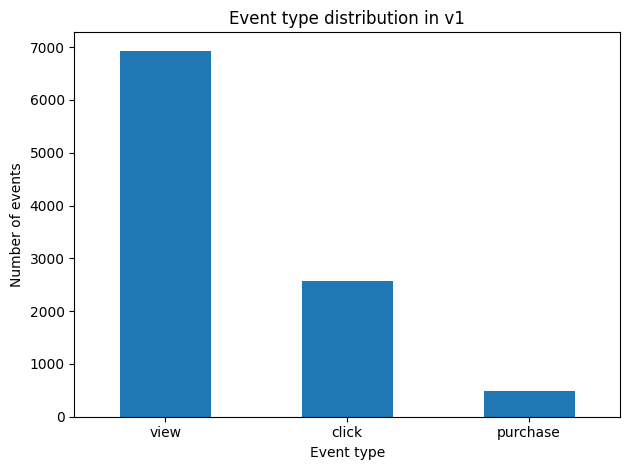

In [43]:
event_counts = v1["event_type"].value_counts()

event_counts.plot(kind="bar")

plt.title("Event type distribution in v1")
plt.xlabel("Event type")
plt.ylabel("Number of events")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

 The generated distribution clearly follows the intended workload structure.

Most generated events are `view` events, while `click` and `purchase` events become progressively less frequent.

Even though the dataset remains synthetic, using non-uniform distributions makes the benchmark more representative than using fully random uniform data.

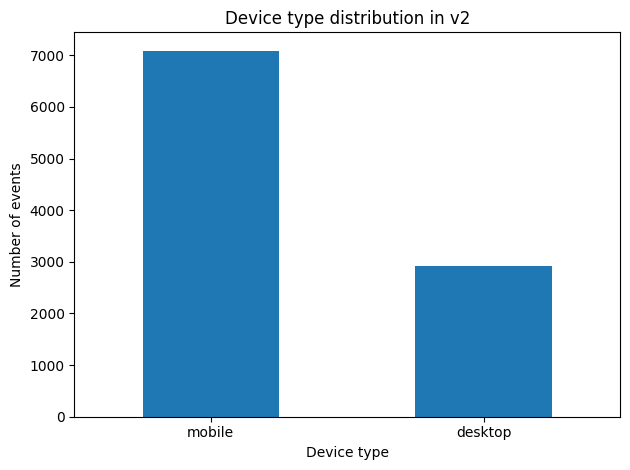

In [44]:
device_counts = v2["device_type"].value_counts()

device_counts.plot(kind="bar")

plt.title("Device type distribution in v2")
plt.xlabel("Device type")
plt.ylabel("Number of events")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The `device_type` column only exists in `v2`.

This column represents the schema evolution introduced during the experiment.

The generated distribution is intentionally dominated by mobile traffic, which again makes the dataset slightly closer to a realistic analytical workload.

## Validating mixed-version reads

Once the datasets were generated and uploaded to MinIO, the next step was validating that both schema versions could still be queried together correctly.

This validation step is important because:

- `v1` does not contain the `device_type` column;
- `v2` introduces the new column;
- both versions still need to remain compatible during analytical reads.

The reader aligns both versions to a unified schema before concatenation and querying.

In [45]:
rows_loaded = df.pivot(
    index="dataset_size_label",
    columns="mode",
    values="rows_loaded"
)

rows_loaded = rows_loaded.loc[["S", "M", "L"]]

rows_loaded

mode,mixed,v1,v2
dataset_size_label,,,
S,20000,10000,10000
M,200000,100000,100000
L,2000000,1000000,1000000


The benchmark confirms that the `mixed` mode correctly combines both schema versions.

For every dataset size, the number of loaded rows in `mixed` mode is approximately twice the value observed for `v1` or `v2` individually.

This validates that both dataset versions are successfully loaded together before the analytical query is executed.

## Query runtime

After validating correctness, the next objective was evaluating the runtime cost introduced by schema evolution.

The figure below compares query runtime for:

- `v1`
- `v2`
- `mixed`

The expectation was that the `mixed` mode would require additional processing because both schema versions must be aligned before querying.

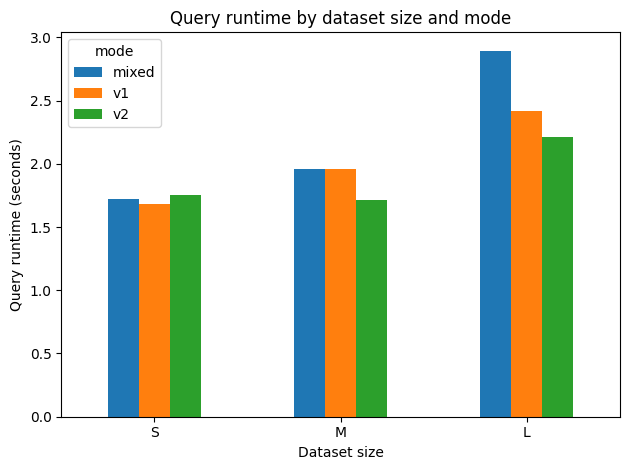

In [46]:
pivot_query = df.pivot(
    index="dataset_size_label",
    columns="mode",
    values="query_time_s"
)

pivot_query = pivot_query.loc[["S", "M", "L"]]

pivot_query.plot(kind="bar")

plt.title("Query runtime by dataset size and mode")
plt.xlabel("Dataset size")
plt.ylabel("Query runtime (seconds)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The benchmark results follow the expected trend.

For all dataset sizes, the `mixed` mode produces the highest query runtime because the reader must:

1. load both dataset versions;
2. align schemas;
3. concatenate both tables;
4. execute the analytical query.

The additional overhead becomes more visible for the largest benchmark configuration (`L`), where the `mixed` mode clearly requires more processing than reading a single schema version.

## Object layout and storage behavior

The datasets are stored in MinIO using separate prefixes for each schema version.

This makes it possible to observe how the reader interacts with the object-storage layout during mixed-version reads.

In [47]:
df[[
    "dataset_size_label",
    "mode",
    "object_count",
    "total_stored_bytes"
]]

,dataset_size_label,mode,object_count,total_stored_bytes
0,S,v1,1,209621
1,S,v2,1,211554
2,S,mixed,2,421175
3,M,v1,1,1682301
4,M,v2,1,1696930
5,M,mixed,2,3379231
6,L,v1,1,12382576
7,L,v2,1,12522307
8,L,mixed,2,24904883


The object count remains fully coherent across all benchmark configurations:

- `v1` reads one object;
- `v2` reads one object;
- `mixed` reads both objects.

The total stored size also roughly doubles in `mixed` mode because both dataset versions are accessed together.

This behavior confirms that the reader interacts with the expected objects during mixed-version reads.

## Transfer performance

Once the read workflow was validated, the benchmark also measured upload and download throughput between the local environment and MinIO object storage.

In [48]:
throughput_columns = [
    "dataset_size_label",
    "mode",
    "upload_throughput_mb_s",
    "download_throughput_mb_s"
]

df[throughput_columns]

,dataset_size_label,mode,upload_throughput_mb_s,download_throughput_mb_s
0,S,v1,0.269727,0.292344
1,S,v2,0.269727,0.292344
2,S,mixed,0.269727,0.292344
3,M,v1,2.098488,2.065462
4,M,v2,2.098488,2.065462
5,M,mixed,2.098488,2.065462
6,L,v1,11.969096,16.018165
7,L,v2,11.969096,16.018165
8,L,mixed,11.969096,16.018165


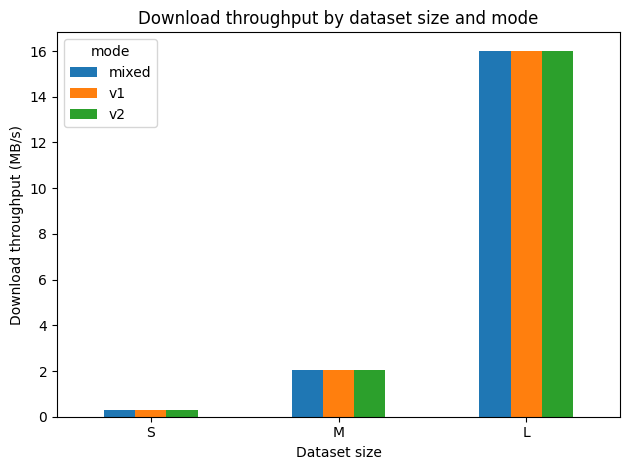

In [49]:
pivot_download = df.pivot(
    index="dataset_size_label",
    columns="mode",
    values="download_throughput_mb_s"
)

pivot_download = pivot_download.loc[["S", "M", "L"]]

pivot_download.plot(kind="bar")

plt.title("Download throughput by dataset size and mode")
plt.xlabel("Dataset size")
plt.ylabel("Download throughput (MB/s)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The throughput values scale consistently with dataset size.

At the same time, differences between reading modes remain limited, which suggests that the transfer pipeline behaves similarly for `v1`, `v2`, and `mixed`.

Since the benchmark runs locally with Docker and MinIO, the throughput values should be interpreted as relative measurements rather than production cloud performance.

## Listing time

The benchmark also measures object listing time during the workflow execution.

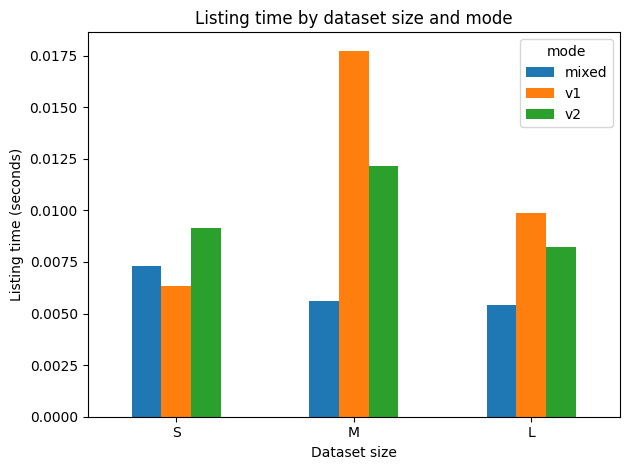

In [50]:
pivot_listing = df.pivot(
    index="dataset_size_label",
    columns="mode",
    values="listing_time_s"
)

pivot_listing = pivot_listing.loc[["S", "M", "L"]]

pivot_listing.plot(kind="bar")

plt.title("Listing time by dataset size and mode")
plt.xlabel("Dataset size")
plt.ylabel("Listing time (seconds)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Listing time remains very small throughout the benchmark.

Small variations appear between configurations, but the overall cost remains negligible compared to query execution time.

This behavior is expected because the benchmark only manipulates a limited number of objects.

## Interpretation

Overall, the experiment validates the main objective of the project: supporting schema evolution without breaking compatibility with older datasets.

The implementation successfully supports:

- independent reads of `v1`;
- independent reads of `v2`;
- backward-compatible mixed reads across both versions.

The schema contract plays a central role because it guarantees that all dataset versions are aligned to a unified schema before querying.

The benchmark also highlights the main trade-off of the current approach:

- mixed-version reads improve compatibility;
- but they introduce additional processing overhead.

Despite this overhead, the workflow behaved consistently across all tested dataset sizes.

## Limitations

Several limitations remain in the current experiment.

First, the benchmark was executed locally using Docker and MinIO. The results therefore do not represent production cloud performance.

Second, only one benchmark run was executed for each configuration. Running multiple iterations and averaging the results would improve measurement reliability.

Finally, the schema evolution scenario remains intentionally simple and only introduces one nullable column (`device_type`).

More complex schema changes would require additional compatibility logic.

## Conclusion

This project demonstrates a complete schema evolution workflow on S3-compatible object storage.

The implementation successfully combines:

- versioned Parquet datasets;
- schema contracts;
- MinIO object storage;
- backward-compatible reads;
- automated benchmark execution.

The benchmark confirms that mixed-version reads remain possible after schema evolution while maintaining a coherent and reproducible workflow across multiple dataset sizes.